# Odseki - Data Exploration
This notebook lets you inspect the `odseki_processed.csv` file column by column.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

df = pd.read_csv('odseki_processed.csv')

print(f'Total rows: {len(df)}')
print(f'Total columns: {len(df.columns)}')
print(f'\nColumns: {list(df.columns)}')

Total rows: 53254
Total columns: 25

Columns: ['ggo', 'odsek', 'povrsina', 'katgozd', 'ohranjen', 'relief', 'nagib', 'nvod', 'nvdo', 'tarifa_sm', 'tarifa_je', 'tarifa_oi', 'tarifa_bu', 'tarifa_hr', 'tarifa_pl', 'tarifa_tl', 'tarifa_ml', 'spravilo', 'razdalja', 'odprtost', 'pozar', 'intgosp', 'grt1', 'rk_gurs', 'ponor_c']


## Code → Naziv lookup tables
Loads the original `.gpkg` to build lookup tables so you can see what each numeric code means.
These are for inspection only — not added to the processed CSV.

In [ ]:
gdf_raw = gpd.read_file('odseki_gozdno.gpkg', ignore_geometry=True)

lookup_pairs = [
    ('katgozd',  'katgozd_naziv'),
    ('ohranjen', 'ohranjen_naziv'),
    ('relief',   'relief_naziv'),
    ('polpokr',  'polpokr_naziv'),
    ('lega',     'lega_naziv'),
    ('spravilo', 'spravilo_naziv'),
    ('pozar',    'pozar_naziv'),
    ('intgosp',  'intgosp_naziv'),
    ('grt1',     'grt1_naziv'),
]

lookups = {}
for code_col, naziv_col in lookup_pairs:
    if code_col in gdf_raw.columns and naziv_col in gdf_raw.columns:
        lookup = gdf_raw[[code_col, naziv_col]].drop_duplicates().dropna().sort_values(code_col)
        lookup.columns = ['code', 'naziv']
        lookups[code_col] = lookup
        print(f'\n--- {code_col} ---')
        display(lookup.reset_index(drop=True))
    else:
        print(f'Skipping {code_col} / {naziv_col} — not found in gpkg')

KeyboardInterrupt: 

## Decoded view — first 100 rows with naziv labels
Shows the processed data with a decoded label column inserted next to each coded column.

In [4]:
df_decoded = df.copy()

for code_col, lookup in lookups.items():
    if code_col in df_decoded.columns:
        mapping = lookup.set_index('code')['naziv'].to_dict()
        idx = df_decoded.columns.get_loc(code_col) + 1
        decoded_col = code_col + '_naziv'
        df_decoded.insert(idx, decoded_col, df_decoded[code_col].map(mapping))

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
df_decoded.head(100)

,ggo,odsek,povrsina,katgozd,katgozd_naziv,ohranjen,ohranjen_naziv,relief,relief_naziv,nagib,nvod,nvdo,tarifa_sm,tarifa_je,tarifa_oi,tarifa_bu,tarifa_hr,tarifa_pl,tarifa_tl,tarifa_ml,spravilo,spravilo_naziv,razdalja,odprtost,pozar,pozar_naziv,intgosp,intgosp_naziv,grt1,grt1_naziv,rk_gurs,ponor_c,nv_srednja
0,9,31001,16.57,1,NaN,3,NaN,1,NaN,20,820,910,52,52,50,52,50,52,48,48,1,S TRAKTORJEM,150,80,3,SREDNJA OGROŽENOST,4,VELIKA INTENZIVNOST,632,NaN,9,10.90,865.00
1,9,31002,31.37,1,NaN,4,NaN,1,NaN,20,675,825,34,33,31,31,27,29,25,25,1,S TRAKTORJEM,150,100,3,SREDNJA OGROŽENOST,4,VELIKA INTENZIVNOST,632,NaN,9,5.10,750.00
2,9,31003,20.00,1,NaN,1,NaN,2,NaN,25,850,1040,52,52,52,52,48,52,48,48,1,S TRAKTORJEM,150,100,3,SREDNJA OGROŽENOST,4,VELIKA INTENZIVNOST,632,NaN,7,6.70,945.00
3,9,31004,23.42,1,NaN,1,NaN,1,NaN,25,830,960,52,52,52,52,52,52,50,50,1,S TRAKTORJEM,100,100,3,SREDNJA OGROŽENOST,4,VELIKA INTENZIVNOST,632,NaN,7,7.30,895.00
4,9,31005,18.53,1,NaN,1,NaN,1,NaN,30,920,1150,52,52,52,52,48,52,48,48,1,S TRAKTORJEM,250,90,3,SREDNJA OGROŽENOST,4,VELIKA INTENZIVNOST,681,NaN,7,4.10,1035.00
5,9,31006A,13.27,1,NaN,1,NaN,2,NaN,20,720,865,52,52,50,52,48,52,48,48,1,S TRAKTORJEM,250,80,3,SREDNJA OGROŽENOST,4,VELIKA INTENZIVNOST,632,NaN,9,4.70,792.50
6,9,31006B,2.24,1,NaN,2,NaN,1,NaN,25,700,780,51,51,46,51,50,51,48,48,1,S TRAKTORJEM,100,100,3,SREDNJA OGROŽENOST,4,VELIKA INTENZIVNOST,751,NaN,9,4.30,740.00
7,9,31007,13.19,1,NaN,1,NaN,1,NaN,25,730,860,52,52,52,52,52,53,48,48,4,KOMBINIRANO I,200,40,3,SREDNJA OGROŽENOST,5,ZELO VELIKA INTENZIVNOST,632,NaN,7,4.60,795.00
8,9,31008,13.79,1,NaN,1,NaN,1,NaN,30,780,880,52,52,52,52,52,53,50,50,4,KOMBINIRANO I,300,70,3,SREDNJA OGROŽENOST,5,ZELO VELIKA INTENZIVNOST,632,NaN,9,3.20,830.00
9,9,31009,20.46,1,NaN,1,NaN,2,NaN,35,660,1130,51,51,51,52,51,51,46,46,4,KOMBINIRANO I,300,85,3,SREDNJA OGROŽENOST,4,VELIKA INTENZIVNOST,632,NaN,7,5.40,895.00


## First 100 rows — processed CSV only (no labels)

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.2f}'.format)

df.head(100)

## Null counts per column

In [5]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
null_summary = pd.DataFrame({'null_count': null_counts, 'null_%': null_pct})
null_summary[null_summary['null_count'] > 0].sort_values('null_%', ascending=False)

,null_count,null_%


## Basic statistics — numeric columns

In [ ]:
df.describe()

## Basic statistics — categorical columns

In [6]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'\n--- {col} ---')
    print(df[col].value_counts().head(20))


--- odsek ---
odsek
05074     9
05013A    9
06053     8
07044     8
06021B    8
07031B    8
09050B    8
07093     8
09050A    8
07013     8
05013B    8
07039     8
07083     8
05039A    8
05039B    8
06021A    8
06018A    8
06018B    8
07090     8
06075     8
Name: count, dtype: int64

--- spravilo ---
spravilo
1    41839
4     7638
2     1925
       690
3      603
5      559
Name: count, dtype: int64

--- pozar ---
pozar
4    25328
3    22375
2     3741
1     1383
       427
Name: count, dtype: int64


## Distribution plots — numeric columns
One histogram per numeric column.

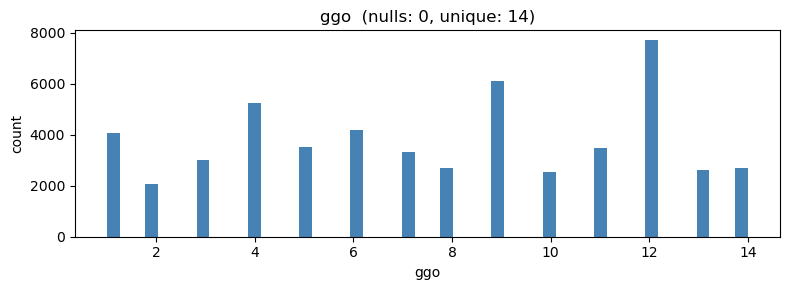

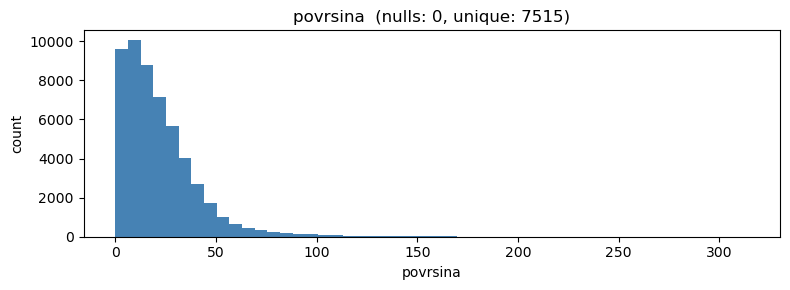

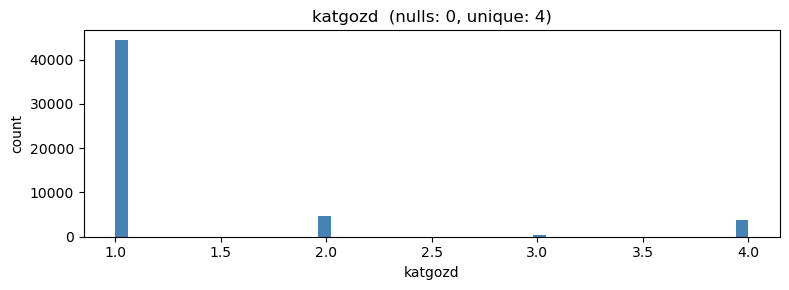

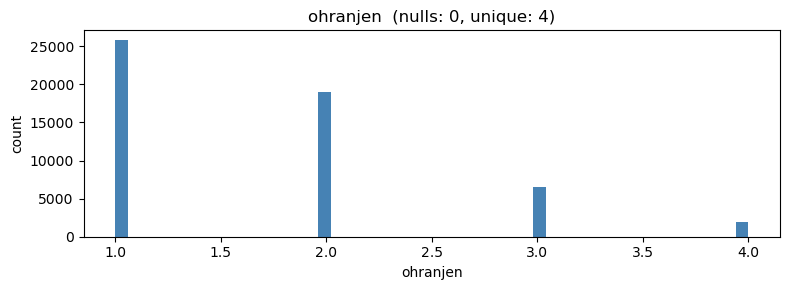

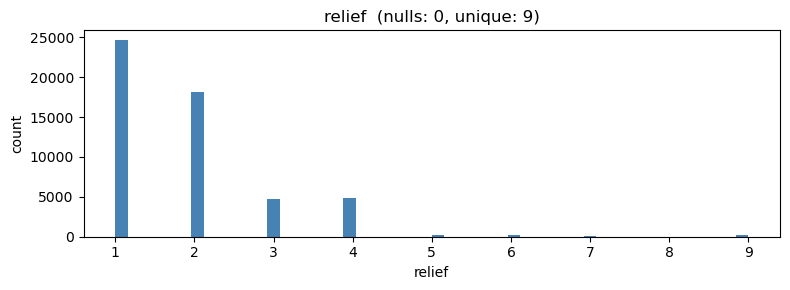

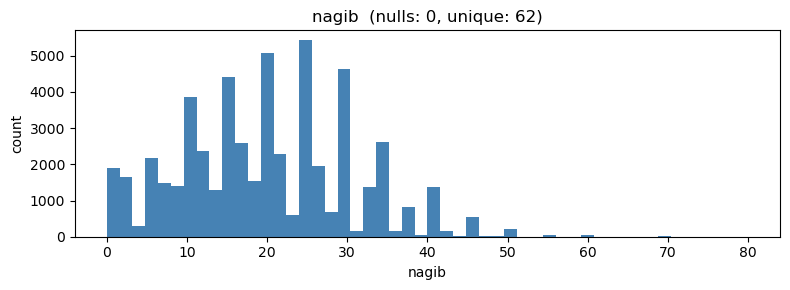

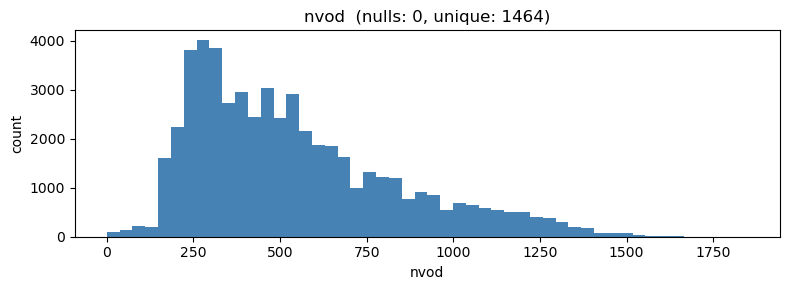

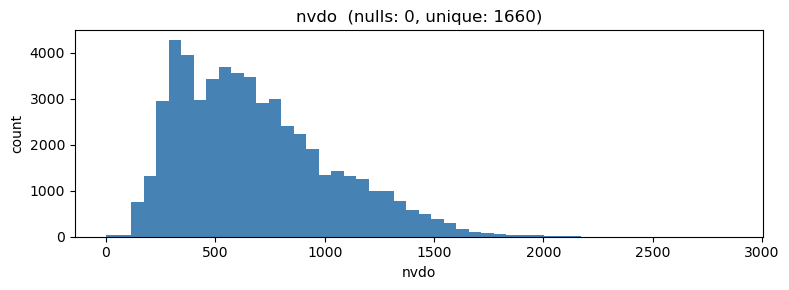

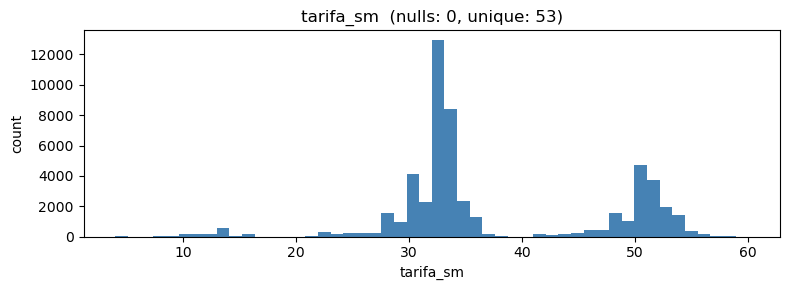

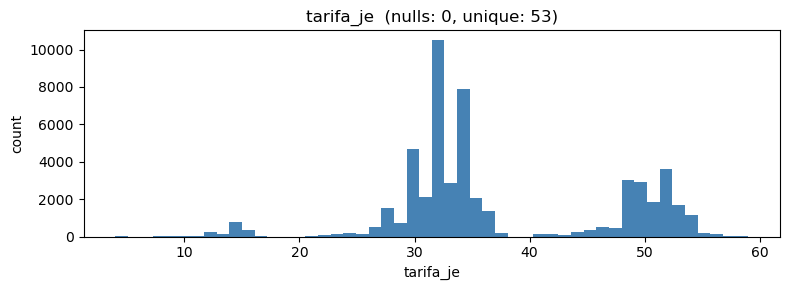

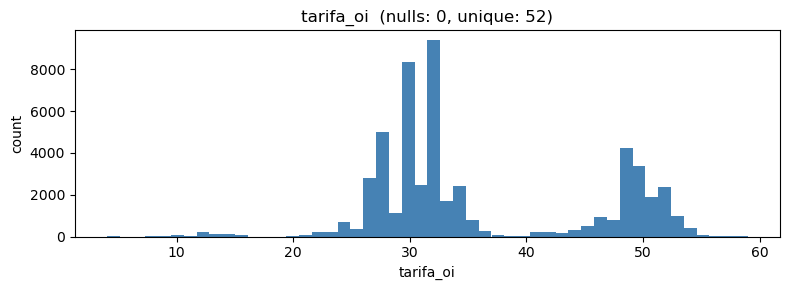

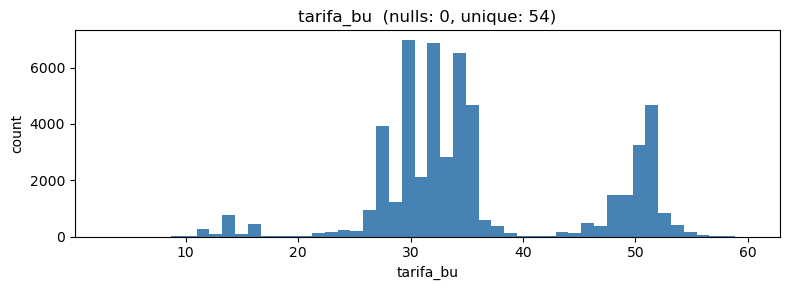

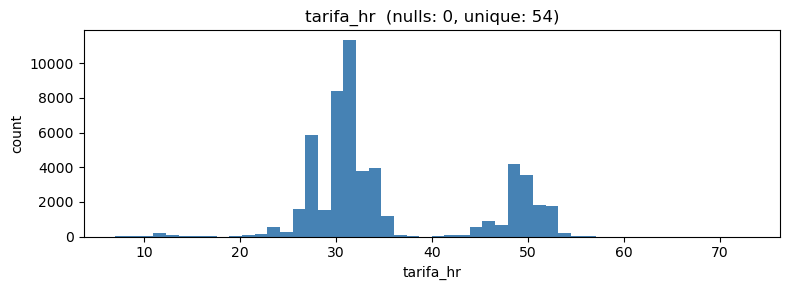

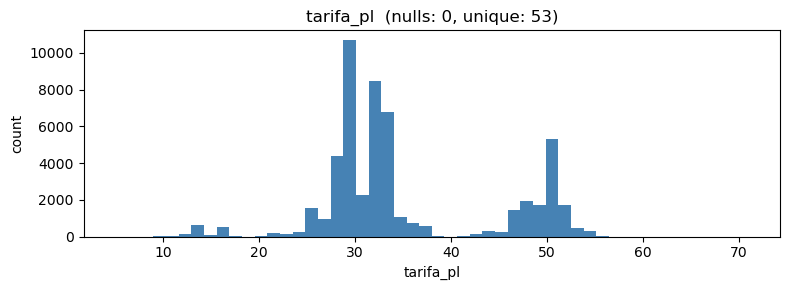

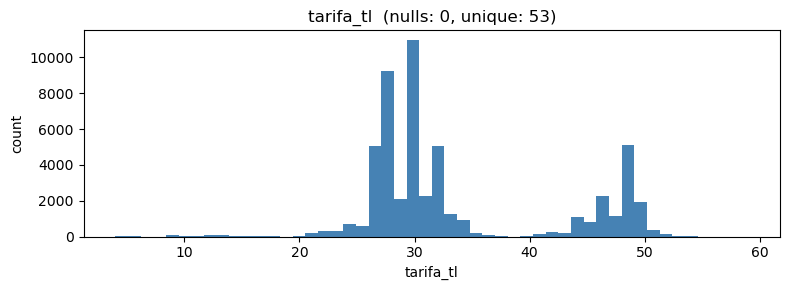

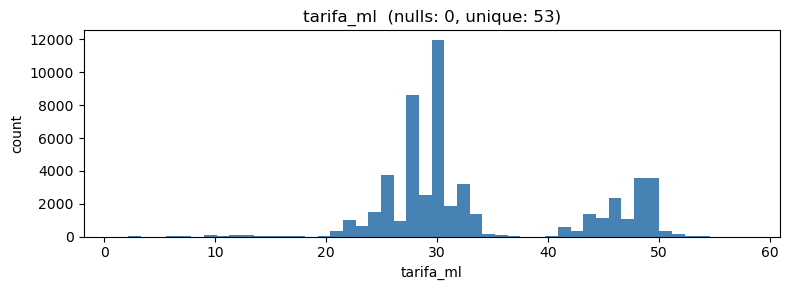

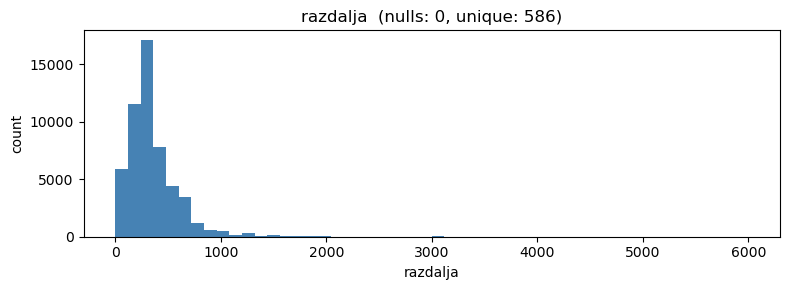

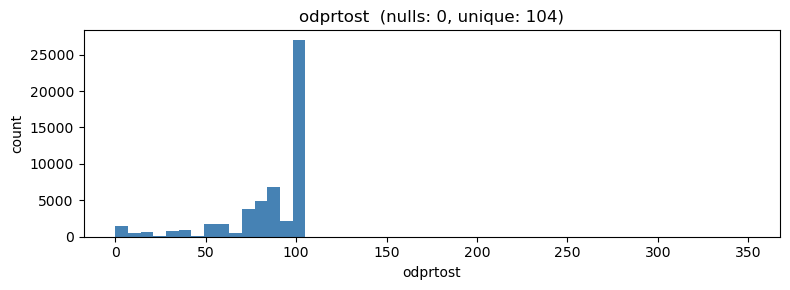

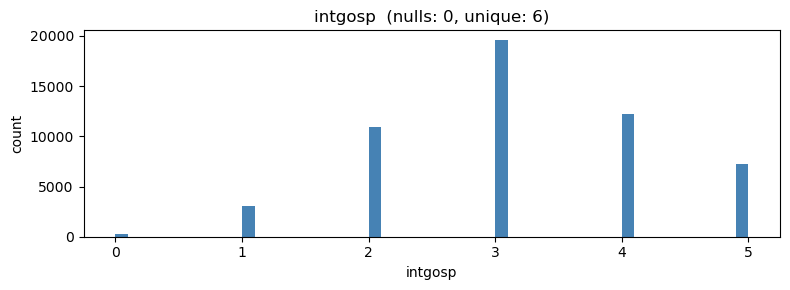

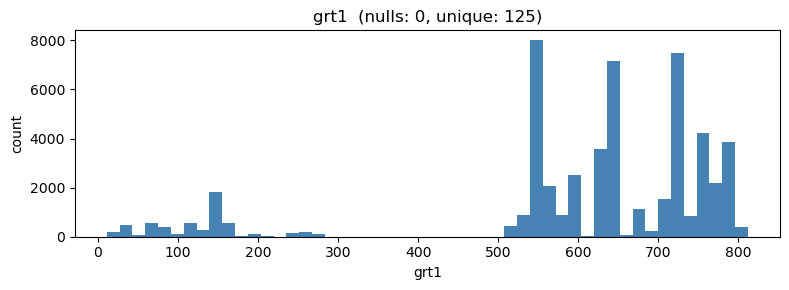

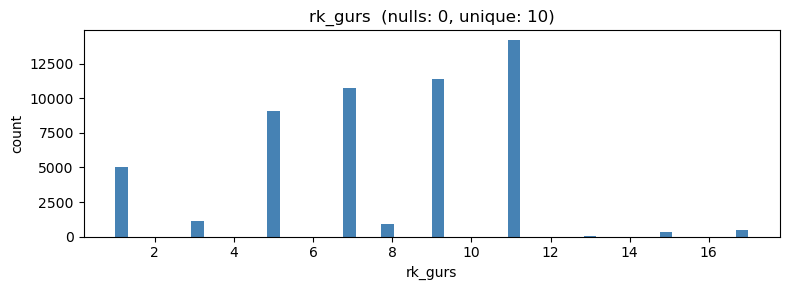

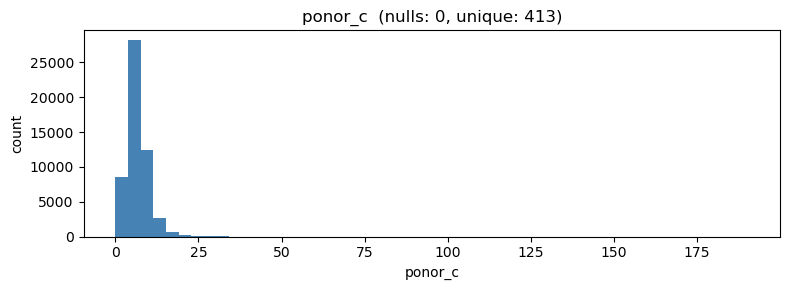

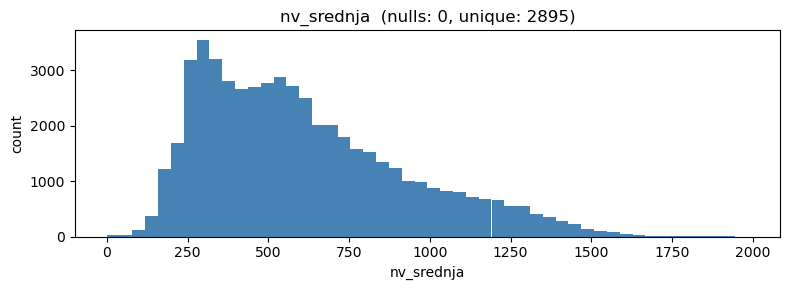

In [7]:
num_cols = df.select_dtypes(include='number').columns.tolist()

for col in num_cols:
    fig, ax = plt.subplots(figsize=(8, 3))
    data = df[col].dropna()
    ax.hist(data, bins=50, color='steelblue', edgecolor='none')
    ax.set_title(f'{col}  (nulls: {df[col].isnull().sum()}, unique: {df[col].nunique()})')
    ax.set_xlabel(col)
    ax.set_ylabel('count')
    plt.tight_layout()
    plt.show()

## Inspect a specific column in detail
Change `col_name` to whichever column you want to look at more closely.

In [8]:
col_name = 'katgozd'  # <-- change this

print(f'Column: {col_name}')
print(f'Type: {df[col_name].dtype}')
print(f'Nulls: {df[col_name].isnull().sum()} ({df[col_name].isnull().mean()*100:.1f}%)')
print(f'Unique values: {df[col_name].nunique()}')
print(f'\nFirst 50 values:')
print(df[col_name].head(50).to_string())
print(f'\nValue counts (top 30):')
if col_name in lookups:
    mapping = lookups[col_name].set_index('code')['naziv'].to_dict()
    vc = df[col_name].value_counts().head(30).reset_index()
    vc.columns = ['code', 'count']
    vc['naziv'] = vc['code'].map(mapping)
    display(vc)
else:
    print(df[col_name].value_counts().head(30))

Column: katgozd
Type: int64
Nulls: 0 (0.0%)
Unique values: 4

First 50 values:
0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    3
12    1
13    1
14    4
15    1
16    4
17    1
18    4
19    1
20    4
21    1
22    1
23    1
24    1
25    1
26    1
27    1
28    1
29    1
30    1
31    1
32    1
33    1
34    1
35    4
36    4
37    1
38    1
39    1
40    1
41    1
42    1
43    1
44    1
45    1
46    1
47    1
48    1
49    1

Value counts (top 30):


,code,count,naziv
0,1,44398,NaN
1,2,4577,NaN
2,4,3883,NaN
3,3,396,NaN


## Tarifa columns side by side
Quick overview of all tarifa columns together.

In [9]:
tarifa_cols = [c for c in df.columns if c.startswith('tarifa_')]
if tarifa_cols:
    print('Tarifa columns summary:')
    display(df[tarifa_cols].describe())
    print(f'\nFirst 50 rows:')
    display(df[tarifa_cols].head(50))
else:
    print('No tarifa columns found.')

Tarifa columns summary:


,tarifa_sm,tarifa_je,tarifa_oi,tarifa_bu,tarifa_hr,tarifa_pl,tarifa_tl,tarifa_ml
count,53254.00,53254.00,53254.00,53254.00,53254.00,53254.00,53254.00,53254.00
mean,37.46,37.17,35.99,35.89,35.35,35.23,33.64,33.61
std,9.74,9.72,9.56,9.35,8.83,9.16,8.53,8.86
min,4.00,4.00,4.00,3.00,7.00,5.00,4.00,1.00
25%,32.00,32.00,30.00,30.00,30.00,30.00,28.00,28.00
50%,34.00,34.00,32.00,33.00,32.00,32.00,30.00,30.00
75%,49.00,48.00,48.00,45.00,45.00,44.00,42.00,44.00
max,60.00,59.00,59.00,60.00,73.00,71.00,59.00,58.00



First 50 rows:


,tarifa_sm,tarifa_je,tarifa_oi,tarifa_bu,tarifa_hr,tarifa_pl,tarifa_tl,tarifa_ml
0,52,52,50,52,50,52,48,48
1,34,33,31,31,27,29,25,25
2,52,52,52,52,48,52,48,48
3,52,52,52,52,52,52,50,50
4,52,52,52,52,48,52,48,48
5,52,52,50,52,48,52,48,48
6,51,51,46,51,50,51,48,48
7,52,52,52,52,52,53,48,48
8,52,52,52,52,52,53,50,50
9,51,51,51,52,51,51,46,46


## Filter rows by condition
Example: show odseki where tarifa_sm is above a threshold.

In [10]:
# Example filter — adjust as needed
if 'tarifa_sm' in df.columns:
    filtered = df[df['tarifa_sm'] > 50]
    print(f'Rows with tarifa_sm > 50: {len(filtered)}')
    display(filtered.head(50))

Rows with tarifa_sm > 50: 9570


,ggo,odsek,povrsina,katgozd,ohranjen,relief,nagib,nvod,nvdo,tarifa_sm,tarifa_je,tarifa_oi,tarifa_bu,tarifa_hr,tarifa_pl,tarifa_tl,tarifa_ml,spravilo,razdalja,odprtost,pozar,intgosp,grt1,rk_gurs,ponor_c,nv_srednja
0,9,31001,16.57,1,3,1,20,820,910,52,52,50,52,50,52,48,48,1,150,80,3,4,632,9,10.90,865.00
2,9,31003,20.00,1,1,2,25,850,1040,52,52,52,52,48,52,48,48,1,150,100,3,4,632,7,6.70,945.00
3,9,31004,23.42,1,1,1,25,830,960,52,52,52,52,52,52,50,50,1,100,100,3,4,632,7,7.30,895.00
4,9,31005,18.53,1,1,1,30,920,1150,52,52,52,52,48,52,48,48,1,250,90,3,4,681,7,4.10,1035.00
5,9,31006A,13.27,1,1,2,20,720,865,52,52,50,52,48,52,48,48,1,250,80,3,4,632,9,4.70,792.50
6,9,31006B,2.24,1,2,1,25,700,780,51,51,46,51,50,51,48,48,1,100,100,3,4,751,9,4.30,740.00
7,9,31007,13.19,1,1,1,25,730,860,52,52,52,52,52,53,48,48,4,200,40,3,5,632,7,4.60,795.00
8,9,31008,13.79,1,1,1,30,780,880,52,52,52,52,52,53,50,50,4,300,70,3,5,632,9,3.20,830.00
9,9,31009,20.46,1,1,2,35,660,1130,51,51,51,52,51,51,46,46,4,300,85,3,4,632,7,5.40,895.00
11,9,31010B,5.03,3,1,1,25,900,1206,52,52,52,52,50,52,48,48,1,300,100,3,1,681,7,2.60,1053.00
